# **Assignment 2 - The impact of AI on Music Sectors (Individual, Communities and Industries)**


Undergraduate (UG) Group 1
- Joshua Steinke [s4091863]
- Paul Venatt [s4089896]
- Putu Adhi Wiguna [s4097286]

This notebook analyses YouTube comments collected using the query `"AI on music"`. The analysis combines text analysis, topic modelling, sentiment analysis, and user reply network analysis.

***

### Research Question

This project investigates how YouTube audiences discuss the impact of AI on the music sector, and whether different user interaction communities frame this issue differently.

The analysis focuses on three linked aims:

1. Identify the main topics discussed in YouTube comments about AI and music.
2. Construct a user reply network to analyse interaction patterns and influential users.
3. Compare detected user communities with LDA topics to understand whether different communities focus on different aspects of the AI-music debate.

### Success Criteria

The analysis is considered successful if it can:

1. Collect and clean a suitable YouTube comment dataset about AI and music.
2. Identify meaningful discussion topics using NLP and topic modelling.
3. Analyse sentiment to understand whether comments are positive, negative, or neutral.
4. Construct a meaningful user reply network from YouTube reply relationships.
5. Identify influential or important users using centrality measures.
6. Detect user communities in the reply network.
7. Compare topics and sentiment across communities to understand how different groups discuss AI’s impact on the music sector.

#### Data Source and Collection

The dataset was collected from YouTube using the YouTube Data API with the query `"AI on music"`. The dataset includes video metadata, top-level comments, replies, author identifiers, timestamps, comment IDs, parent comment IDs, and reply-to-author information.

The textual fields, especially comment text and reply text, support NLP analysis such as topic modelling and sentiment analysis. The relational fields, especially `author_channel_id`, `reply_to_author_channel_id`, `comment_id`, and `parent_comment_id`, support network analysis by allowing a user reply network to be constructed.

In the network, each node represents a YouTube user. A directed edge from User A to User B means that User A replied to User B. Edge weights represent the number of replies between the same pair of users.

The dataset is limited by the search query, YouTube API access limits, unavailable/deleted comments, videos with disabled comments, and the decision to keep only English-language comments.

In [1]:
# Libraries used
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import re
import json
import nltk
import string
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import pyLDAvis
import pyLDAvis.lda_model
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from networkx.algorithms.community import greedy_modularity_communities
from collections import Counter
from langdetect import detect, LangDetectException # package to detect English language
from nltk.sentiment import SentimentIntensityAnalyzer

## 1. Exploratory Data Analysis (EDA)

In [2]:
with open('./data/youtubeFlatComments_AI_on_music.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

dataset = pd.DataFrame(data['comments'])
dataset.head()

,video_id,video_title,channel_id,channel_title,video_published_at,video_view_count,video_like_count,video_comment_count,comment_id,parent_comment_id,comment_type,author_display_name,author_channel_id,text,text_original,like_count,published_at,updated_at,reply_to_author_display_name,reply_to_author_channel_id
0,Sbv0iX_EyLM,AI Music is Not Music - Adam Neely,UC7kIy8fZavEni8Gzl8NLjOQ,Alex O'Connor,2026-05-13T15:31:35Z,229348,8458,3861,Ugz_vLToQloKib1Dsmt4AaABAg,NaN,top_level,@foxmocs6443,UCinA3pJ4_XChanp3nvpfNsw,Never could have predicted this crossover. Two...,Never could have predicted this crossover. Two...,1441,2026-05-13T15:32:19Z,2026-05-13T15:32:19Z,NaN,NaN
1,Sbv0iX_EyLM,AI Music is Not Music - Adam Neely,UC7kIy8fZavEni8Gzl8NLjOQ,Alex O'Connor,2026-05-13T15:31:35Z,229348,8458,3861,Ugz_vLToQloKib1Dsmt4AaABAg.AWkg3VfSPEZAWkhCufgK72,Ugz_vLToQloKib1Dsmt4AaABAg,reply,@MidnightUnity,UCdisatKsUEaCeliNJ6BdKZg,"I was about to say two of my favourite nerds, ...","I was about to say two of my favourite nerds, ...",28,2026-05-13T15:42:20Z,2026-05-13T15:42:20Z,@foxmocs6443,UCinA3pJ4_XChanp3nvpfNsw
2,Sbv0iX_EyLM,AI Music is Not Music - Adam Neely,UC7kIy8fZavEni8Gzl8NLjOQ,Alex O'Connor,2026-05-13T15:31:35Z,229348,8458,3861,Ugz_vLToQloKib1Dsmt4AaABAg.AWkg3VfSPEZAWkhSyhPznS,Ugz_vLToQloKib1Dsmt4AaABAg,reply,@AdımızAdımız,UCRELhN7padwcwT94a0m0tnQ,fr,fr,1,2026-05-13T15:44:32Z,2026-05-13T15:44:32Z,@foxmocs6443,UCinA3pJ4_XChanp3nvpfNsw
3,Sbv0iX_EyLM,AI Music is Not Music - Adam Neely,UC7kIy8fZavEni8Gzl8NLjOQ,Alex O'Connor,2026-05-13T15:31:35Z,229348,8458,3861,Ugz_vLToQloKib1Dsmt4AaABAg.AWkg3VfSPEZAWkhd5JSn27,Ugz_vLToQloKib1Dsmt4AaABAg,reply,@mymasmith7848,UC7ps19AcOCVsJB3MzW_qsmQ,"Yeeeeehah, I am so eagerly the next two hours ...","Yeeeeehah, I am so eagerly the next two hours ...",2,2026-05-13T15:46:03Z,2026-05-13T15:46:03Z,@foxmocs6443,UCinA3pJ4_XChanp3nvpfNsw
4,Sbv0iX_EyLM,AI Music is Not Music - Adam Neely,UC7kIy8fZavEni8Gzl8NLjOQ,Alex O'Connor,2026-05-13T15:31:35Z,229348,8458,3861,Ugz_vLToQloKib1Dsmt4AaABAg.AWkg3VfSPEZAWkjpDEB6Po,Ugz_vLToQloKib1Dsmt4AaABAg,reply,@zlquis,UCbhxNik1HRXNuFjBb2nXMvg,Literally my 2 favourite content creators. I'm...,Literally my 2 favourite content creators. I'm...,9,2026-05-13T16:05:11Z,2026-05-13T16:05:11Z,@foxmocs6443,UCinA3pJ4_XChanp3nvpfNsw


In [3]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 14342 entries, 0 to 14341
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   video_id                      14342 non-null  str  
 1   video_title                   14342 non-null  str  
 2   channel_id                    14342 non-null  str  
 3   channel_title                 14342 non-null  str  
 4   video_published_at            14342 non-null  str  
 5   video_view_count              14342 non-null  int64
 6   video_like_count              14342 non-null  int64
 7   video_comment_count           14342 non-null  int64
 8   comment_id                    14342 non-null  str  
 9   parent_comment_id             12011 non-null  str  
 10  comment_type                  14342 non-null  str  
 11  author_display_name           14342 non-null  str  
 12  author_channel_id             14342 non-null  str  
 13  text                          14342 non-nu

## 2. Data Cleaning

### 2.1. Keeping English Comments Only

In [4]:
def check_language(text):
    """Check if comments are in English"""
    try:
        return detect(str(text))
    except LangDetectException:
        return 'unknown'

dataset['language'] = dataset['text'].apply(check_language)
dataset['language'].value_counts().head(10)

language
en         12339
unknown      261
tl           210
so           145
nl           103
fr           102
de            98
cy            98
af            96
id            84
Name: count, dtype: int64

Non-English comments will be removed from the dataset since we will only be working with English comments.

In [5]:
# To confirm if dataset only contains English comments
dataset = dataset[dataset['language'] == 'en']
dataset['language'].unique()

<StringArray>
['en']
Length: 1, dtype: str

### 2.2. Removing Very Short Comments

Very short comments (e.g., comments with less than 3 words) does not really add much meaning regarding users semantic. Hence, they are removed from the dataset.

In [6]:
# Keeps comments with length of 3 or more words
dataset = dataset[dataset['text'].str.split().apply(len) >= 3].reset_index(drop=True)

In [7]:
def clean_comments(text):
    """
    Function to clean comments, the process goes as:
    
    1. Convert comments to use all lowercase
    2. Remove any URLs
    3. Remove any YouTube-style mentions/handles if present
    4. Remove common unicode punctuation
    5. Keeps letters and spaces only
    6. Remove extra whitespaces
    """
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[\u2018\u2019\u201c\u201d\u2014]', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Place the cleaned text comments into a separate column, keep the original text
dataset['cleaned_text'] = dataset['text'].apply(clean_comments)
dataset[['text', 'cleaned_text']].head()

,text,cleaned_text
0,Never could have predicted this crossover. Two...,never could have predicted this crossover two ...
1,"I was about to say two of my favourite nerds, ...",i was about to say two of my favourite nerds b...
2,"Yeeeeehah, I am so eagerly the next two hours ...",yeeeeehah i am so eagerly the next two hours o...
3,Literally my 2 favourite content creators. I'm...,literally my favourite content creators i m ev...
4,"Alex is a pretty good musician himself, so I'm...",alex is a pretty good musician himself so i m ...


## 3. Tokenise and Remove Stopwords

In [8]:
nltk.download('stopwords')

tokeniser = TweetTokenizer()
stemmer = PorterStemmer()

stop_words = stopwords.words('english') + list(string.punctuation)

# Some additional stopwords that might be present in the comments but don't add much meanings
add_stopwords = [
    'ai', 'music', 'song', 'songs', 'video',
    'like', 'just', 'get', 'would', 'could',
    'people', 'peopl', 'make', 'use', 'thing',
    'think', 'one', 'go', 'going', 'want',
    'look', 'sound', 'good', 'really', 'realli',
    'even', 'much', 'say', 'know', 'see', 'also',
    'im', 'ive', 'dont', 'cant', 'youre', 'thats'
]

# Apply the additional stopwords into the base NLTK's English stopwords
stop_words = set(stop_words + add_stopwords)

[nltk_data] Downloading package stopwords to /Users/adhi/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
def tokenise_text(text):
    """
    Function to tokenise the cleaned text comments
    """
    tokens = tokeniser.tokenize(str(text).lower())
    processed_tokens = []
    for token in tokens:
        token = token.strip()
        if not token:
            continue
        if token in stop_words:
            continue
        if token.isdigit():
            continue
        if re.search(r'[a-zA-Z]', token) is None:
            continue

        token = stemmer.stem(token)
        if token not in stop_words and len(token) > 1:
            processed_tokens.append(token)

    return processed_tokens

# Apply the tokenisation onto the cleaned texts
dataset['tokens'] = dataset['cleaned_text'].apply(tokenise_text)

# Join the tokens together, place it into a new column
dataset['processed_text'] = dataset['tokens'].apply(lambda tokens: ' '.join(tokens))

# Add token counts column
dataset['tokens_count'] = dataset['tokens'].apply(len)

dataset[['text', 'cleaned_text', 'tokens', 'processed_text']].head()

,text,cleaned_text,tokens,processed_text
0,Never could have predicted this crossover. Two...,never could have predicted this crossover two ...,"[never, predict, crossov, two, favorit, studi,...",never predict crossov two favorit studi combin
1,"I was about to say two of my favourite nerds, ...",i was about to say two of my favourite nerds b...,"[two, favourit, nerd, studi, actual, nicer, wa...",two favourit nerd studi actual nicer way word ...
2,"Yeeeeehah, I am so eagerly the next two hours ...",yeeeeehah i am so eagerly the next two hours o...,"[yeeeeehah, eagerli, next, two, hour, fine, li...",yeeeeehah eagerli next two hour fine listen
3,Literally my 2 favourite content creators. I'm...,literally my favourite content creators i m ev...,"[liter, favourit, content, creator, adam, tour...",liter favourit content creator adam tour next ...
4,"Alex is a pretty good musician himself, so I'm...",alex is a pretty good musician himself so i m ...,"[alex, pretti, musician, surpris]",alex pretti musician surpris


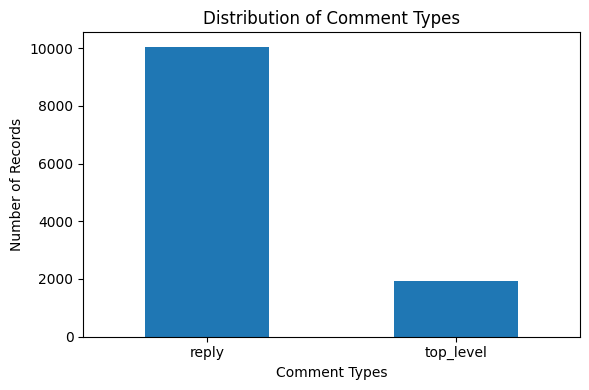

In [10]:
comment_types = dataset['comment_type'].value_counts()

# Plot the comment type counts
plt.figure(figsize=(6, 4))
comment_types.plot(kind='bar')
plt.title('Distribution of Comment Types')
plt.xlabel('Comment Types')
plt.ylabel('Number of Records')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

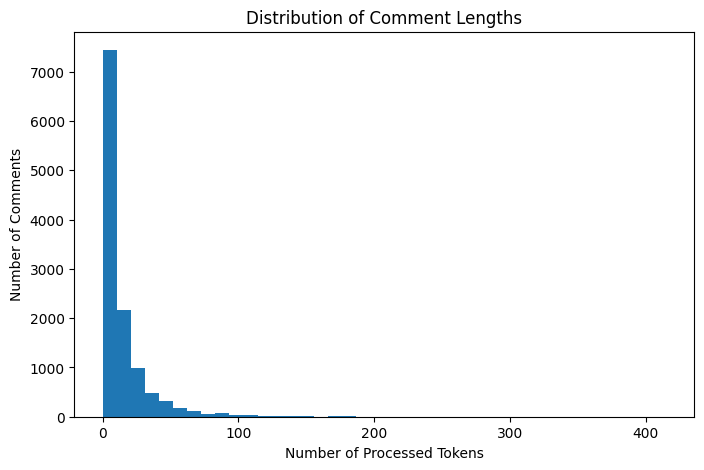

In [11]:
# Plot comment tokens length distribution
plt.figure(figsize=(8, 5))
plt.hist(dataset['tokens_count'], bins=40)
plt.title('Distribution of Comment Lengths')
plt.xlabel('Number of Processed Tokens')
plt.ylabel('Number of Comments')
plt.show()

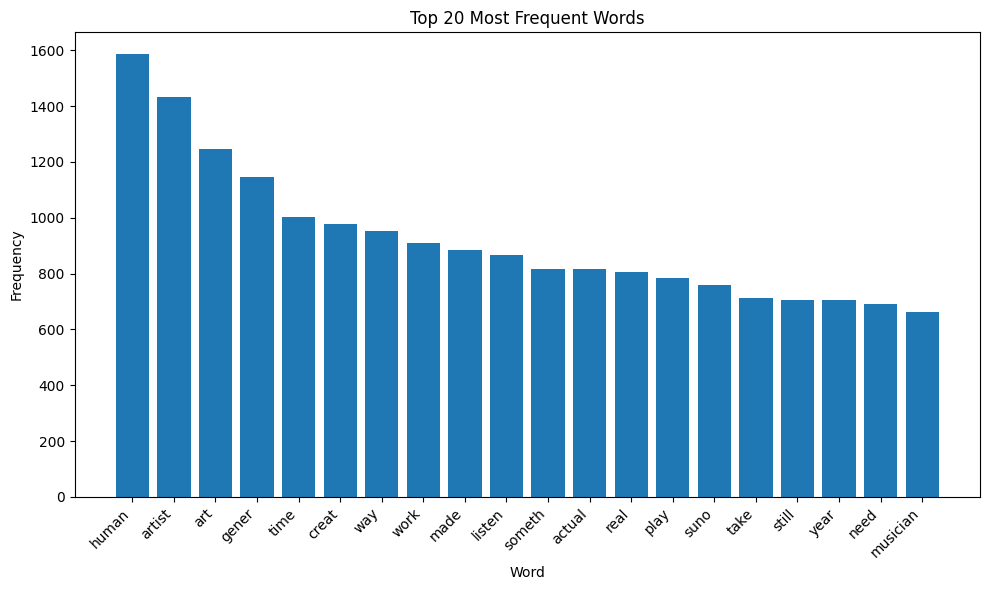

In [12]:
# Plot top 20 most used words
all_tokens = []
for tokens in dataset['tokens']:
    all_tokens.extend(tokens)
word_freq = Counter(all_tokens)

top_words = pd.DataFrame(
    word_freq.most_common(20),
    columns=['word', 'frequency']
)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(top_words['word'], top_words['frequency'])
plt.title('Top 20 Most Frequent Words')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Topic Modelling (LDA)

We use Latent Dirichlet Allocation (LDA) to discover latent topics discussed across cleaned English YouTube comments and replies about AI and music. This helps identify what users are discussing, such as AI music tools, human creativity, copyright, and industry disruption. The topic labels are later connected with user communities in the reply network.

In [13]:
dataset = dataset[dataset['processed_text'].str.strip() != ''].reset_index(drop=True)

vectorizer = CountVectorizer(max_df=0.9, min_df=5, max_features=1000)

"""
@dtm: Document Term Matrix

By observing the shape:
Rows = comments
Columns = selected words/features
"""
dtm = vectorizer.fit_transform(dataset['processed_text'])
print('Document-term matrix shape:', dtm.shape)

Document-term matrix shape: (11886, 1000)


In [14]:
num_topics = 5

# Set and fit the LDA model
LDA_model = LatentDirichletAllocation(n_components=num_topics, random_state=42, learning_method='batch')
LDA_model.fit(dtm)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",5
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [15]:
# Get list of words from CountVectorizer vocabulary
feat_names = vectorizer.get_feature_names_out()

def display_topics(model, feature_names, number_of_words=15):
    """Prints the most associated words for each topic."""
    for topic_id, topic in enumerate(model.components_):
        top_word_indices = topic.argsort()[-number_of_words:][::-1]
        top_words = [feature_names[i] for i in top_word_indices]

        print(f'Topic {topic_id}:')
        print(', '.join(top_words))
        print()

display_topics(model=LDA_model, feature_names=feat_names, number_of_words=15)

Topic 0:
artist, call, someth, comment, mean, differ, gener, definit, write, actual, read, creativ, said, name, creat

Topic 1:
human, suno, creat, play, musician, artist, live, produc, real, time, way, tool, learn, record, instrument

Topic 2:
gener, copyright, youtub, year, right, take, artist, time, money, day, care, everi, compani, content, better

Topic 3:
listen, thank, lol, love, lyric, write, bro, hear, countri, actual, made, got, band, old, back

Topic 4:
art, human, never, feel, work, way, made, need, artist, point, someth, care, gener, person, take



### 4.1. pyLDAvis

pyLDAvis provides an interactive visualisation of the topic model.
Each bubble represents a topic — larger bubbles indicate more prevalent topics,
and the distance between bubbles reflects how distinct the topics are from each other.

In [16]:
"""Displaying pyLDAvis panel"""
pyLDAvis.enable_notebook()
panel = pyLDAvis.lda_model.prepare(LDA_model, dtm, vectorizer, mds='tsne')

pyLDAvis.display(panel)

### 4.2. Word Clouds

We visualise each topic as a word cloud, where larger words have a stronger association with that topic. This makes the themes easier to interpret at a glance.

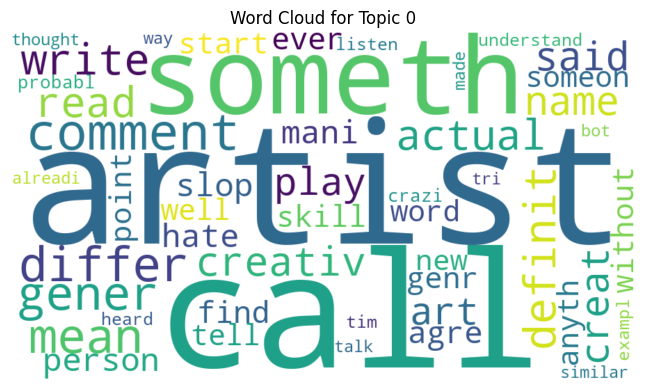

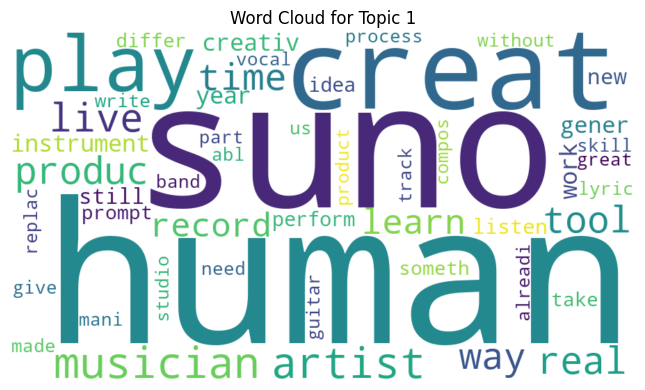

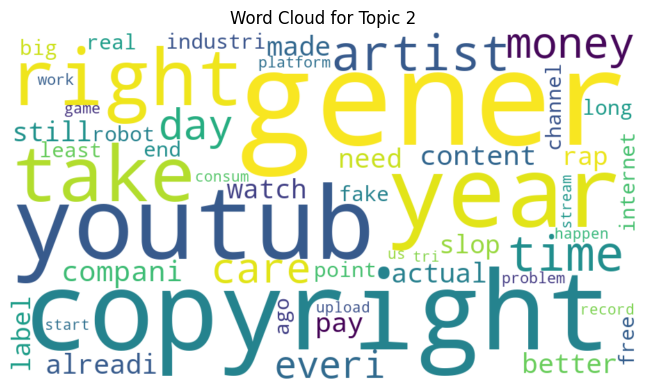

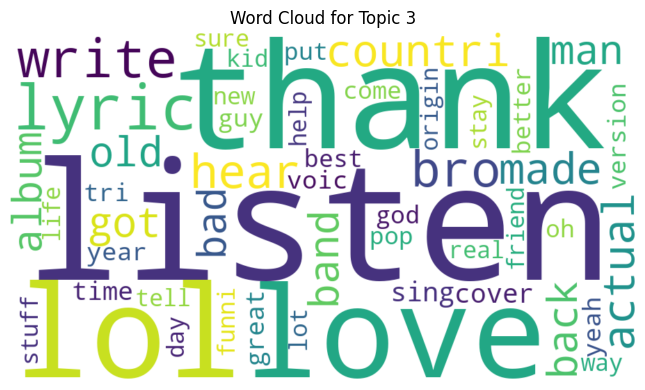

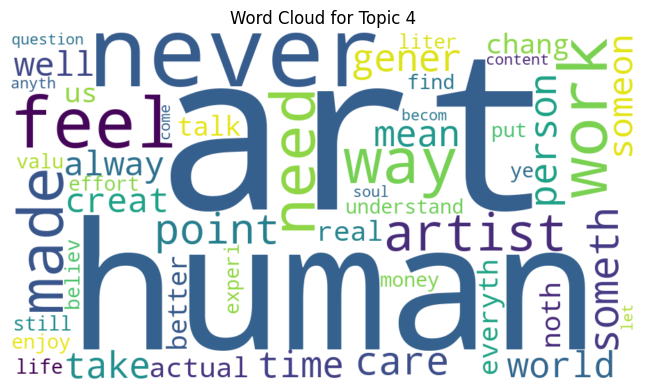

In [17]:
def plot_word_cloud(model, feature_names, topic_idx, number_of_words=50):
    """Function to display the word cloud to identify dominant topics"""
    topic = model.components_[topic_idx]
    top_word_indices = topic.argsort()[-number_of_words:][::-1]
    word_weights = {feature_names[i]: topic[i] for i in top_word_indices}

    # Configure word cloud settings
    wordcloud = WordCloud(width=900, height=500, background_color='white').generate_from_frequencies(word_weights)

    # Plot
    plt.figure(figsize=(8, 4))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud for Topic {topic_idx}')
    plt.tight_layout()
    plt.show()

# Display and generate the word cloud for topics
for topic_index in range(num_topics):
    plot_word_cloud(
        model=LDA_model,
        feature_names=feat_names,
        topic_idx=topic_index,
        number_of_words=50
    )

In [18]:
# Saving the topic words into a table
topics = []
for topic_idx, topic in enumerate(LDA_model.components_):
    top_word_indices = topic.argsort()[-12:][::-1]

    for word_rank, word_idx in enumerate(top_word_indices, start=1):
        topics.append({
            'topic': topic_idx,
            'rank': word_rank,
            'word': feat_names[word_idx],
            'weight': topic[word_idx]
        })

# Put the collected topics into a DataFrame
topics_data = pd.DataFrame(topics)
topics_data.head(10)

,topic,rank,word,weight
0,0,1,artist,336.033623
1,0,2,call,304.433468
2,0,3,someth,268.493152
3,0,4,comment,263.383692
4,0,5,mean,231.731365
5,0,6,differ,229.726019
6,0,7,gener,220.751658
7,0,8,definit,187.382366
8,0,9,write,179.801912
9,0,10,actual,172.113975


### 4.3. Assigning a Dominant Topic to Each Comment

We assign each top-level comment its dominant topic — the topic
that the LDA model assigns the highest probability to.

This lets us later cross-reference topics with the network analysis,
for example by seeing which topics are most associated with
highly central or influential users.

In [19]:
"""
Transform the Document Term Matrix to get the topic distribution
Each row is a comment, each column is a topic probability
"""
topic_dist = LDA_model.transform(dtm)

print('Topic distribution matrix:')
print(f'{topic_dist.shape[0]} comments')
print(f'{topic_dist.shape[1]} topics')

# Add dominant topics and it's probability into a new column in the dataset
dataset['dominant_topic'] = topic_dist.argmax(axis=1)
dataset['dominant_topic_probability'] = topic_dist.max(axis=1)
dataset[['text', 'processed_text', 'dominant_topic', 'dominant_topic_probability']].head()

Topic distribution matrix:
11886 comments
5 topics


,text,processed_text,dominant_topic,dominant_topic_probability
0,Never could have predicted this crossover. Two...,never predict crossov two favorit studi combin,0,0.622747
1,"I was about to say two of my favourite nerds, ...",two favourit nerd studi actual nicer way word ...,3,0.606270
2,"Yeeeeehah, I am so eagerly the next two hours ...",yeeeeehah eagerli next two hour fine listen,3,0.862937
3,Literally my 2 favourite content creators. I'm...,liter favourit content creator adam tour next ...,2,0.883453
4,"Alex is a pretty good musician himself, so I'm...",alex pretti musician surpris,3,0.546767


In [20]:
# Get a summarisation of the topic distribution
topic_summary = (dataset['dominant_topic'].value_counts().sort_index().reset_index())
topic_summary.columns = ['topic', 'number_of_comments']
topic_summary['percentage'] = (topic_summary['number_of_comments'] / len(dataset) * 100).round(2)

topic_summary

,topic,number_of_comments,percentage
0,0,2304,19.38
1,1,2279,19.17
2,2,2148,18.07
3,3,2603,21.90
4,4,2552,21.47


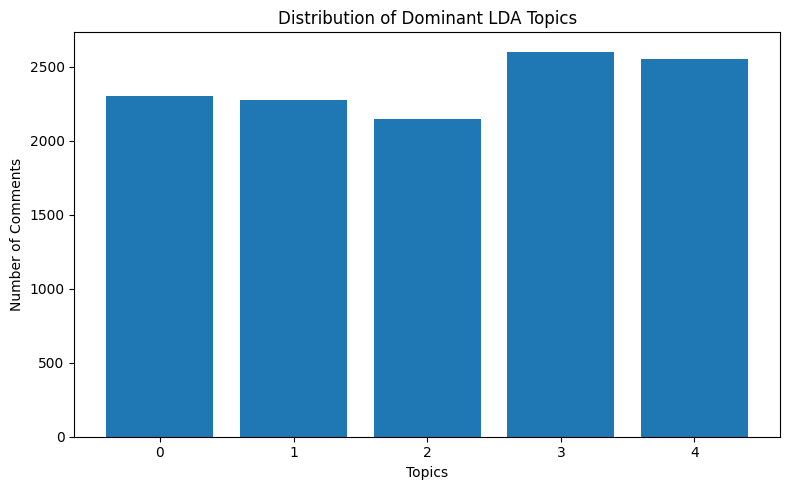

In [21]:
"""Plotting dominant topics distribution"""
plt.figure(figsize=(8, 5))
plt.bar(
    topic_summary['topic'].astype(str),
    topic_summary['number_of_comments']
)

plt.title('Distribution of Dominant LDA Topics')
plt.xlabel('Topics')
plt.ylabel('Number of Comments')
plt.tight_layout()
plt.show()

Based on the generate Word Clouds, a topic sentence was manually labelled for each topic ID.

In [22]:
"""Manually labelling the topic based on generated word clouds"""
topic_labels = {
    0: 'AI-assisted songwriting and music production',
    1: 'Music industry and artist disruption',
    2: 'Human creativity versus AI-generated content',
    3: 'Copyright, copying, and audience reactions',
    4: 'Human value, learning, and adaptation to AI'
}

dataset['topic_label'] = dataset['dominant_topic'].map(topic_labels)

After identifying dominant discussion topics using LDA, the analysis moves to the interaction structure of the YouTube comments. Since the dataset contains a large number of replies, a directed weighted user reply network was constructed. This allows the project to identify influential users and interaction communities, then compare whether different communities focus on different AI-music topics.

## 5. Sentiment Analysis

In addition to LDA topic modelling, semantic analysis was used to compare each comment with predefined AI-music impact themes. While LDA identifies topics based on word co-occurrence, semantic similarity uses sentence embeddings to compare the meaning of comments with broader conceptual themes. This helps validate whether the discovered topics align with the main research focus of AI’s impact on the music sector.

In [23]:
nltk.download('vader_lexicon')
analyser = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/adhi/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [24]:
def clean_sentiment(text):
    """"
    VADER model works better with natural sentences.
    Hence, a lighter text cleaning function was applied then stored into a
    separate column different from @processed_text.

    Removed URLs and extra whitespaces
    """
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

dataset['sentiment_text'] = dataset['text'].apply(clean_sentiment)
dataset[['text', 'sentiment_text']].head()

,text,sentiment_text
0,Never could have predicted this crossover. Two...,Never could have predicted this crossover. Two...
1,"I was about to say two of my favourite nerds, ...","I was about to say two of my favourite nerds, ..."
2,"Yeeeeehah, I am so eagerly the next two hours ...","Yeeeeehah, I am so eagerly the next two hours ..."
3,Literally my 2 favourite content creators. I'm...,Literally my 2 favourite content creators. I'm...
4,"Alex is a pretty good musician himself, so I'm...","Alex is a pretty good musician himself, so I'm..."


In [25]:
def get_vader_compound_score(text):
    """
    Returns: VADER compound score

    Negative values indicate negative sentiment
    Positive values indicate positive sentiment
    """
    sentiment_scores = analyser.polarity_scores(str(text))
    return sentiment_scores['compound']


dataset['sentiment_score'] = dataset['sentiment_text'].apply(get_vader_compound_score)
dataset[['sentiment_text', 'sentiment_score']].head()

,sentiment_text,sentiment_score
0,Never could have predicted this crossover. Two...,0.5093
1,"I was about to say two of my favourite nerds, ...",0.9184
2,"Yeeeeehah, I am so eagerly the next two hours ...",0.6329
3,Literally my 2 favourite content creators. I'm...,0.0000
4,"Alex is a pretty good musician himself, so I'm...",0.6334


In [26]:
def classify_sentiment(score):
    """
    >= 0.5 is positive, <= -0.05 is negative
    Any score between them are neutral
    """
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

dataset['sentiment_label'] = dataset['sentiment_score'].apply(classify_sentiment)
dataset[['sentiment_text', 'sentiment_score', 'sentiment_label']].head()

,sentiment_text,sentiment_score,sentiment_label
0,Never could have predicted this crossover. Two...,0.5093,Positive
1,"I was about to say two of my favourite nerds, ...",0.9184,Positive
2,"Yeeeeehah, I am so eagerly the next two hours ...",0.6329,Positive
3,Literally my 2 favourite content creators. I'm...,0.0000,Neutral
4,"Alex is a pretty good musician himself, so I'm...",0.6334,Positive


In [27]:
# Count how many comments fall into each sentiment category
sentiment_summary = (dataset['sentiment_label'].value_counts().reset_index())
sentiment_summary.columns = ['sentiment_label', 'number_of_comments']

# Convert counts into percentages for easier interpretation
sentiment_summary['percentage'] = (
    sentiment_summary['number_of_comments'] / len(dataset) * 100
).round(2)

sentiment_summary

,sentiment_label,number_of_comments,percentage
0,Positive,6096,51.29
1,Negative,2907,24.46
2,Neutral,2883,24.26


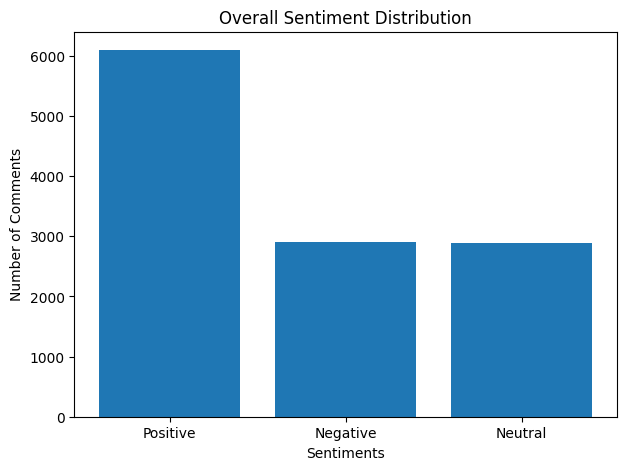

In [28]:
# Plot sentiment distribution
plt.figure(figsize=(7, 5))
plt.bar(sentiment_summary['sentiment_label'], sentiment_summary['number_of_comments'])

plt.title('Overall Sentiment Distribution')
plt.xlabel('Sentiments')
plt.ylabel('Number of Comments')
plt.show()

The overall sentiment distribution shows that positive comments are the most common in the dataset, followed by negative and neutral comments. This suggests that the YouTube discussion around AI and the music sector is not purely negative, even though the topic involves concerns such as copyright, artist disruption, and human creativity.

The large number of positive comments may indicate that many users view AI music tools as useful, interesting, or creatively valuable. However, the presence of a substantial number of negative comments also shows that there are clear concerns or criticisms within the discussion. Neutral comments may include factual statements, questions, or comments where the sentiment is not strongly expressed.

Overall, this plot provides a semantic overview of the dataset by showing that audience reactions to AI in music are mixed, but lean more positive than negative.

### 5.1. Sentiment Score by Topic

In [29]:
"""
Calculate the average sentiment score for each LDA topic
This helps show whether some topics are more positive or negative than others
"""
sentiment_by_topic = (
    dataset
    .groupby('topic_label')
    .agg(
        number_of_comments=('sentiment_score', 'count'),
        average_sentiment=('sentiment_score', 'mean'),
        median_sentiment=('sentiment_score', 'median')
    )
    .sort_values('average_sentiment', ascending=False)
    .reset_index()
)

sentiment_by_topic['average_sentiment'] = sentiment_by_topic['average_sentiment'].round(3)
sentiment_by_topic['median_sentiment'] = sentiment_by_topic['median_sentiment'].round(3)
sentiment_by_topic

,topic_label,number_of_comments,average_sentiment,median_sentiment
0,Music industry and artist disruption,2279,0.298,0.382
1,"Copyright, copying, and audience reactions",2603,0.251,0.318
2,"Human value, learning, and adaptation to AI",2552,0.152,0.052
3,AI-assisted songwriting and music production,2304,0.112,0.000
4,Human creativity versus AI-generated content,2148,0.084,0.000


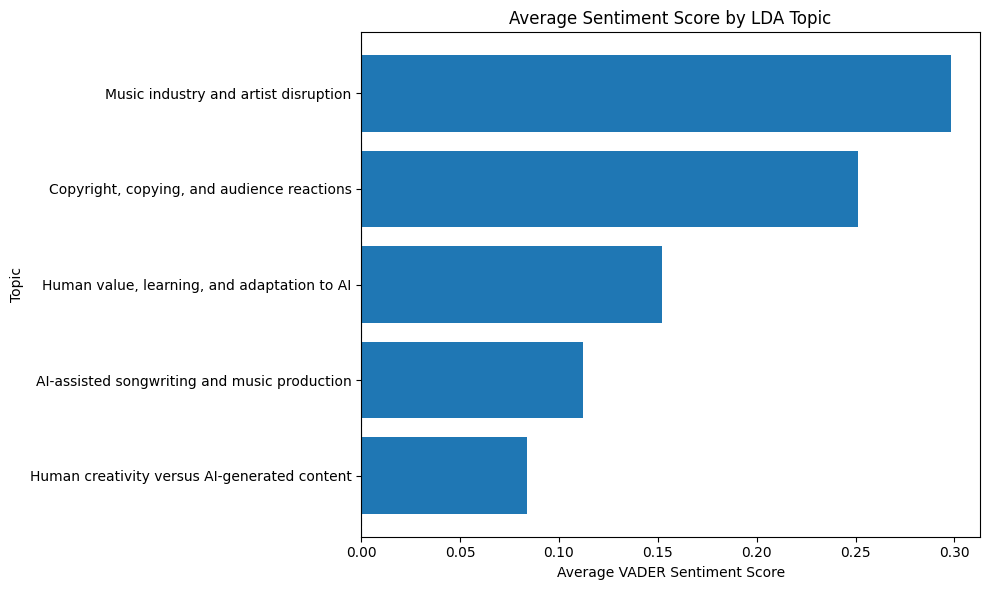

In [30]:
# Plot
plt.figure(figsize=(10, 6))
plt.barh(sentiment_by_topic['topic_label'], sentiment_by_topic['average_sentiment'])

plt.title('Average Sentiment Score by LDA Topic')
plt.xlabel('Average VADER Sentiment Score')
plt.ylabel('Topic')
plt.axvline(0, linestyle='--')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

This plot compares the average VADER sentiment score across the LDA topics. All topics have a positive average sentiment score, which suggests that, on average, comments in each topic are more positive than negative. However, the strength of positivity differs across topics.

The topic **“AI-assisted songwriting and music production”** has the highest average sentiment score. This suggests that comments about using AI for songwriting, lyric generation, music creation, and production tools tend to be more positive. This may reflect user interest in AI as a practical or creative tool.

The topic **“Human creativity versus AI-generated content”** has the lowest average sentiment score among the topics. This suggests that discussions about whether AI can replace or replicate human creativity are more cautious or critical. This is reasonable because this topic is more closely linked to concerns about authenticity, artistic value, and the role of human artists.

Overall, the plot shows that sentiment differs by discussion theme. Comments focused on practical AI music tools appear more positive, while comments focused on human creativity and AI-generated content are less positive.

In [31]:
# Count sentiment labels within each topic
sentiment_topic_counts = (
    dataset
    .groupby(['topic_label', 'sentiment_label'])
    .size()
    .reset_index(name='count')
)

# Calculate the total number of comments in each topic
sentiment_topic_counts['topic_total'] = (
    sentiment_topic_counts
    .groupby('topic_label')['count']
    .transform('sum')
)

# Convert counts into percentages within each topic
sentiment_topic_counts['percentage'] = (
    sentiment_topic_counts['count'] /
    sentiment_topic_counts['topic_total'] * 100
).round(2)

sentiment_topic_counts.head()

,topic_label,sentiment_label,count,topic_total,percentage
0,AI-assisted songwriting and music production,Negative,540,2304,23.44
1,AI-assisted songwriting and music production,Neutral,792,2304,34.38
2,AI-assisted songwriting and music production,Positive,972,2304,42.19
3,"Copyright, copying, and audience reactions",Negative,491,2603,18.86
4,"Copyright, copying, and audience reactions",Neutral,606,2603,23.28


In [32]:
# Convert the table into a pivot table for plotting
sentiment_topic_pivot = sentiment_topic_counts.pivot(
    index='topic_label',
    columns='sentiment_label',
    values='percentage'
).fillna(0)

sentiment_topic_pivot

sentiment_label,Negative,Neutral,Positive
topic_label,,,
AI-assisted songwriting and music production,23.44,34.38,42.19
"Copyright, copying, and audience reactions",18.86,23.28,57.86
Human creativity versus AI-generated content,30.82,26.58,42.60
"Human value, learning, and adaptation to AI",28.37,21.36,50.27
Music industry and artist disruption,21.50,16.19,62.31


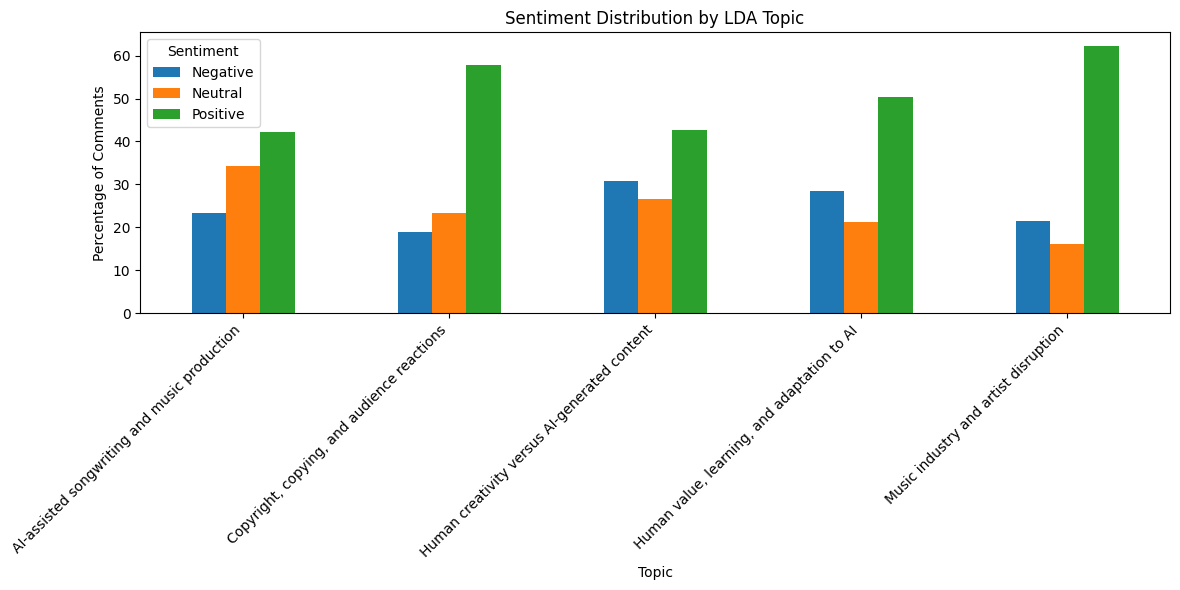

In [33]:
sentiment_topic_pivot.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Sentiment Distribution by LDA Topic')
plt.xlabel('Topic')
plt.ylabel('Percentage of Comments')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

This plot shows the percentage of positive, neutral, and negative comments within each LDA topic. Across all topics, positive comments make up the largest proportion, which is consistent with the overall sentiment distribution. However, the balance between positive, neutral, and negative sentiment varies by topic.

- The topic **“AI-assisted songwriting and music production”** has the highest proportion of positive comments and a relatively lower proportion of negative comments. This supports the interpretation that users are more favourable when discussing AI as a tool for creating lyrics, songs, melodies, or recordings.

- In contrast, **“Human creativity versus AI-generated content”** and **“Human value, learning, and adaptation to AI”** have relatively higher proportions of negative comments. This suggests that when the discussion shifts from practical tools to broader questions about creativity, authenticity, work, and human value, users express more concern or criticism.

- The topic **“Copyright, copying, and audience reactions”** also contains a large positive proportion, but still includes a noticeable share of negative and neutral comments. This reflects the mixed nature of copyright-related discussion, where some users may be reacting positively to content while others raise concerns about copying, originality, or ownership.

Overall, this plot adds a semantic layer to the topic modelling results. It shows not only what users discuss, but also how positively or negatively they tend to discuss each theme.

In [34]:
# Print example comments from each sentiment category
# This helps validate whether the automatic sentiment labels are reasonable
for sentiment in ['Positive', 'Neutral', 'Negative']:
    print(f'\n------------------')
    print(f'{sentiment} comments\n')

    examples = (
        dataset[dataset['sentiment_label'] == sentiment]
        .sort_values('sentiment_score', ascending=(sentiment == 'Negative'))
        .head(5)
    )

    for _, row in examples.iterrows():
        print('-', row['text'][:300])


------------------
Positive comments

- @Lina_EHM  "And all this idiots that really flood the market, creating songs without what I just told. Ppl that do prompts like: "Make me a bad boy hip hop song" hitting create and publishing this crap."


That is exactly what's to be expected to AI generators like Suno and that is exactly why th
- ​@Nick-t5xive never claimed to be anything except a guy who wrote lyrics thats it , i said it would be great if somehow i made some money but i would still write regardless, im not offended by your position at all , you are entitled to hate whatever you want , i do have a question though , would tha
- @aahhhhhhhhhhhhh You have no idea what my stance on AI is, and you would guess wrong. We're talking about art. As you already said you don't care what "Western visual artists" (including a musician and a writer lol) are doing, what in the world are you still doing pinging me?

I'll do one wrap-up to
- Well put. Artificial Intelligence doesn't have any im

## 6. User Replies Network

After assigning each comment a dominant LDA topic, the next stage is to analyse the interaction structure of the YouTube discussion. Since the dataset contains many replies, a directed weighted user reply network was constructed. In this network, each node represents a YouTube user, and each directed edge represents one user replying to another user. Edge weights represent the number of replies between the same pair of users.

In [35]:
"""Filtering user reply records"""
replies_data = dataset[
    (dataset['comment_type'] == 'reply') &
    (dataset['author_channel_id'].notna()) &
    (dataset['reply_to_author_channel_id'].notna())
].copy()

# Remove self-replies
replies_data = replies_data[
    replies_data['author_channel_id'] != replies_data['reply_to_author_channel_id']
].copy()

print('Number of reply rows:', len(replies_data))
print('Unique replying users:', replies_data['author_channel_id'].nunique())
print('Unique replied-to users:', replies_data['reply_to_author_channel_id'].nunique())

Number of reply rows: 9552
Unique replying users: 5927
Unique replied-to users: 899


In [36]:
# Building edge list
edge_data = (
    replies_data
    .groupby([
        'author_channel_id',
        'reply_to_author_channel_id'
    ])
    .agg(
        weight=('comment_id', 'count'),
        source_name=('author_display_name', 'first'),
        target_name=('reply_to_author_display_name', 'first')
    )
    .reset_index()
    .rename(columns={
        'author_channel_id': 'source',
        'reply_to_author_channel_id': 'target'
    })
)

edge_data.head()

,source,target,weight,source_name,target_name
0,UC-143ND7KXdjfcqMXbZH5Ng,UCZllv4L7S3t16kgLuN33NiA,1,@Tooruofficial1,@GramGramAnimations
1,UC-1yf1p7WRvY3z2L4MamGHg,UCgfZdkzvVUHf4vKPj-R4_7A,1,@Page-Humbuckers1973,@controlledburst
2,UC-3GMsrNch7u7837iLI26bA,UCPTa2aqVGv1bxCMlwkWOxYA,1,@vocecaiunocontodomalakoi7541,@ZBspicey
3,UC-3tABkXUfdRJFQ1Zx39MbA,UC9-tyozbTOKwJPZ6lEvAb4g,2,@jackweitzman6697,@foxyrand
4,UC-5zrhkAivIM0jKEWyLgVJg,UCxB219ufjxNVadCO3GPpotA,1,@AliBreee,@therealunclebbq


In [37]:
# Building directed weight graph
G = nx.from_pandas_edgelist(
    edge_data,
    source='source',
    target='target',
    edge_attr=['weight', 'source_name', 'target_name'],
    create_using=nx.DiGraph()
)

print('Number of nodes:', G.number_of_nodes())
print('Number of edges:', G.number_of_edges())
print('Network density:', nx.density(G))

Number of nodes: 6766
Number of edges: 7403
Network density: 0.00016173646808889018


The low network density is expected for a YouTube reply network because most users interact with only a small number of other users. This suggests that the discussion is sparse rather than fully connected, which is common in social media interaction networks.

## 7. SNA Centrality Measures

Centrality measures were calculated to identify structurally important users in the reply network. Weighted in-degree identifies users who received many replies, weighted out-degree identifies users who actively replied to others, PageRank identifies users who are influential within the reply structure, and betweenness centrality identifies users who connect different parts of the network.

In [38]:
# Weighted in-degree and out-degree
in_degree = dict(G.in_degree(weight='weight'))
out_degree = dict(G.out_degree(weight='weight'))

# PageRank
pagerank = nx.pagerank(G, weight='weight')

# Convert edge weight into distance for betweenness centrality
# Higher reply frequency = stronger connection = shorter distance
for u, v, edge_attributes in G.edges(data=True):
    edge_attributes['distance'] = 1 / edge_attributes['weight']

# Betweenness
betweenness = nx.betweenness_centrality(G, weight='distance', normalized=True)

In [39]:
# Creating centrality table that includes usernames
user_names = {}
for _, row in replies_data.iterrows():
    user_names[row['author_channel_id']] = row['author_display_name']
    user_names[row['reply_to_author_channel_id']] = row['reply_to_author_display_name']

centrality_data = pd.DataFrame({
    'id': list(G.nodes()),
    'username': [user_names.get(node, node) for node in G.nodes()],
    'weighted_in_degree': [in_degree.get(node, 0) for node in G.nodes()],
    'weighted_out_degree': [out_degree.get(node, 0) for node in G.nodes()],
    'pagerank': [pagerank.get(node, 0) for node in G.nodes()],
    'betweenness': [betweenness.get(node, 0) for node in G.nodes()]
})

centrality_data.head()

,id,username,weighted_in_degree,weighted_out_degree,pagerank,betweenness
0,UC-143ND7KXdjfcqMXbZH5Ng,@Tooruofficial1,0,1,0.000082,0.000000
1,UCZllv4L7S3t16kgLuN33NiA,@GramGramAnimations,96,1,0.006894,0.000005
2,UC-1yf1p7WRvY3z2L4MamGHg,@Page-Humbuckers1973,0,1,0.000082,0.000000
3,UCgfZdkzvVUHf4vKPj-R4_7A,@controlledburst,65,0,0.004857,0.000000
4,UC-3GMsrNch7u7837iLI26bA,@vocecaiunocontodomalakoi7541,0,1,0.000082,0.000000


In [40]:
# Top users based on weighted in degree centrality
centrality_data.sort_values('weighted_in_degree', ascending=False).head(10)

,id,username,weighted_in_degree,weighted_out_degree,pagerank,betweenness
515,UC4PIiYewI1YGyiZvgNlJNrA,@CharlesCornellStudios,100,4,0.004832,0.000019
94,UCUJDTsUzE0s6xAwdNlwfXCA,@Prog-t9d,97,0,0.004528,0.000000
120,UCOrK28-rchatUNaXf8QgBPw,@halsti99,97,0,0.003391,0.000000
1,UCZllv4L7S3t16kgLuN33NiA,@GramGramAnimations,96,1,0.006894,0.000005
62,UCAiYGga6xkRUnXYhaGd0WNA,@PuRpLe0MiSt,95,0,0.004938,0.000000
170,UC93SAoFOTG75UTTKa7CTCrw,@andriypredmyrskyy7791,95,0,0.002302,0.000000
224,UCQFtmcpgr7NkcvuaCCJdViA,@believershope,94,0,0.003935,0.000000
368,UC8j3fdKGM2d-rv1qFp_QxLw,@cbobschloss,93,0,0.004665,0.000000
279,UC7wIrwsFD-4n9m6I-NxA5yA,@MattEdwards1,90,0,0.003792,0.000000
28,UCUhCiBjuc9YwfeYqQwQjlpA,@skirkstar,90,0,0.004281,0.000000


In [41]:
# Top users based on weighted out degree centrality
centrality_data.sort_values('weighted_out_degree', ascending=False).head(10)

,id,username,weighted_in_degree,weighted_out_degree,pagerank,betweenness
168,UCmeU2DYiVy80wMBGZzEWnbw,@PaulJLipsky,9,50,0.000658,0.00001
5931,UCrEJc2qvac8VfdVySj00t3w,@TevezNedro,0,40,0.000082,0.00000
6685,UCzFQwsVY0lcAOoorfABJ4_w,@EliMercerOfficial,0,37,0.000082,0.00000
3817,UCXkIMilviTtF_EFYC4ylOJg,@aahhhhhhhhhhhhh,0,35,0.000082,0.00000
2843,UCOQfLCVu3VCrdwA_kqWtIEQ,@yuna17994,0,25,0.000082,0.00000
3276,UCSh5zO3a_AZWmzukVmwvVJQ,@RusticRoadCountry,0,25,0.000082,0.00000
6060,UCsN7_WaJWqh1MCgGfye3_ew,@ReactInfo54,0,24,0.000082,0.00000
4640,UCf658Qpw_ou8oL_mityeP-A,@broughttoyouopmsoulrevival,0,24,0.000082,0.00000
6252,UCuajBd4igtzl5xjvKS9mYtw,@conspiracymusic,0,24,0.000082,0.00000
5858,UCqRNyvicCCqLIySuLK8DdIQ,@eightcoins4401,0,23,0.000082,0.00000


In [42]:
# Top users based on PageRank centrality
centrality_data.sort_values('pagerank', ascending=False).head(10)

,id,username,weighted_in_degree,weighted_out_degree,pagerank,betweenness
1,UCZllv4L7S3t16kgLuN33NiA,@GramGramAnimations,96,1,0.006894,0.000005
390,UCRwX7nPX7kMbN8MEHSZG3ZQ,@Ellary_Rosewood,23,0,0.006644,0.000000
222,UCZJWUueXq2Gbvr8znMnBvzA,@sillybilly1489,80,0,0.005329,0.000000
39,UCKxT19NqLN5AYl4imxG2E5Q,@nathanbanks2354,79,0,0.005109,0.000000
62,UCAiYGga6xkRUnXYhaGd0WNA,@PuRpLe0MiSt,95,0,0.004938,0.000000
3,UCgfZdkzvVUHf4vKPj-R4_7A,@controlledburst,65,0,0.004857,0.000000
515,UC4PIiYewI1YGyiZvgNlJNrA,@CharlesCornellStudios,100,4,0.004832,0.000019
368,UC8j3fdKGM2d-rv1qFp_QxLw,@cbobschloss,93,0,0.004665,0.000000
9,UCxB219ufjxNVadCO3GPpotA,@therealunclebbq,81,0,0.004575,0.000000
165,UCOEkCtSMFWVm3en3618lzcA,@davisthedaviskids2574,72,0,0.004552,0.000000


In [43]:
# Top users based on betweenness centrality
centrality_data.sort_values('betweenness', ascending=False).head(10)

,id,username,weighted_in_degree,weighted_out_degree,pagerank,betweenness
515,UC4PIiYewI1YGyiZvgNlJNrA,@CharlesCornellStudios,100,4,0.004832,0.000019
730,UCfEJZmjVvEXt0RWURwP5Uag,@staticloop-o8r,29,9,0.002409,0.000017
305,UC7epYXoxGQlErIpBOYoCj9A,@AIAutomationLabs,34,17,0.002177,0.000010
168,UCmeU2DYiVy80wMBGZzEWnbw,@PaulJLipsky,9,50,0.000658,0.000010
7,UC9-tyozbTOKwJPZ6lEvAb4g,@foxyrand,37,1,0.003407,0.000007
1,UCZllv4L7S3t16kgLuN33NiA,@GramGramAnimations,96,1,0.006894,0.000005
183,UCA9ddiLbmBNN1pDlEGDKiuw,@MergoGreat1,59,7,0.002221,0.000004
553,UCkmyqYWJ0x-nZjRMH6rI9tw,@NeoSoulReimahe,6,19,0.000499,0.000002
439,UCyGuZR2aP0RDpbXRhJycmRQ,@Burnrate,33,2,0.001628,0.000002
1807,UCr2Pmqtaz9Uk9yK7Io_m0RQ,@AlekseyMaksimovichPeshkov,14,4,0.000822,0.000001


In [44]:
# Saving centrality data for later use
centrality_data.to_csv('./data/replyNetworkCentrality.csv', index=False)

## 8. Community Detection

Community detection was applied to identify groups of users who interacted more closely with each other. The directed reply network was converted to an undirected graph for community detection because the aim was to find interaction clusters rather than model reply direction. Edge weights were retained so that repeated interactions between users contributed more strongly to community formation.

In [45]:
G_undirected = G.to_undirected()
communities = greedy_modularity_communities(G_undirected, weight='weight')

print('Number of communities detected:', len(communities))
print('Largest community size:', len(max(communities, key=len)))

Number of communities detected: 252
Largest community size: 445


In [46]:
# Assigning community labels to user
community_lookup = {}
for id, nodes in enumerate(communities):
    for node in nodes:
        community_lookup[node] = id

centrality_data['community'] = centrality_data['id'].map(community_lookup)
centrality_data.head()

,id,username,weighted_in_degree,weighted_out_degree,pagerank,betweenness,community
0,UC-143ND7KXdjfcqMXbZH5Ng,@Tooruofficial1,0,1,0.000082,0.000000,1
1,UCZllv4L7S3t16kgLuN33NiA,@GramGramAnimations,96,1,0.006894,0.000005,1
2,UC-1yf1p7WRvY3z2L4MamGHg,@Page-Humbuckers1973,0,1,0.000082,0.000000,5
3,UCgfZdkzvVUHf4vKPj-R4_7A,@controlledburst,65,0,0.004857,0.000000,5
4,UC-3GMsrNch7u7837iLI26bA,@vocecaiunocontodomalakoi7541,0,1,0.000082,0.000000,9


In [47]:
# Get a summary of communities
community_summary = (
    centrality_data
    .groupby('community')
    .agg(
        number_of_users=('id', 'count'),
        avg_pagerank=('pagerank', 'mean'),
        max_pagerank=('pagerank', 'max'),
        avg_betweenness=('betweenness', 'mean'),
        max_betweenness=('betweenness', 'max')
    )
    .sort_values('number_of_users', ascending=False)
    .reset_index()
)

community_summary.head(10)

,community,number_of_users,avg_pagerank,max_pagerank,avg_betweenness,max_betweenness
0,0,445,0.000147,0.004281,7.366477e-10,2.622466e-07
1,1,440,0.000183,0.006894,1.122992e-07,1.880527e-05
2,2,383,0.000144,0.003935,5.363616e-09,8.523014e-07
3,3,347,0.000153,0.003961,4.471544e-09,6.556165e-07
4,4,278,0.000147,0.004528,6.288887e-10,1.748311e-07
5,5,268,0.000155,0.004857,0.000000e+00,0.000000e+00
6,6,265,0.000146,0.002136,3.298699e-09,2.841005e-07
7,7,244,0.000153,0.004575,1.495737e-08,3.649598e-06
8,8,215,0.000144,0.002302,1.016460e-10,2.185388e-08
9,9,177,0.000158,0.005109,3.457111e-09,4.152238e-07


In [48]:
# Add community labels back to the dataset
dataset['author_community'] = dataset['author_channel_id'].map(community_lookup)
dataset[['author_display_name', 'comment_type', 'topic_label', 'author_community', 'text']].head()

,author_display_name,comment_type,topic_label,author_community,text
0,@foxmocs6443,top_level,AI-assisted songwriting and music production,26.0,Never could have predicted this crossover. Two...
1,@MidnightUnity,reply,"Copyright, copying, and audience reactions",26.0,"I was about to say two of my favourite nerds, ..."
2,@mymasmith7848,reply,"Copyright, copying, and audience reactions",26.0,"Yeeeeehah, I am so eagerly the next two hours ..."
3,@zlquis,reply,Human creativity versus AI-generated content,26.0,Literally my 2 favourite content creators. I'm...
4,@CamxCam.,reply,"Copyright, copying, and audience reactions",26.0,"Alex is a pretty good musician himself, so I'm..."


## 9. Connecting Communities to LDA Topics

After detecting user communities, the community labels were mapped back to the comment dataset. This allows comparison of the dominant LDA topics across different interaction communities, showing whether different user groups focus on different aspects of AI's impact on music.

In [49]:
# Topic distribution by community
community_topic_summary = (
    dataset
    .dropna(subset=['author_community'])
    .groupby(['author_community', 'topic_label'])
    .size()
    .reset_index(name='comment_count')
)

# Convert it into percentages for each community
community_topic_summary['community_total'] = (
    community_topic_summary
    .groupby('author_community')['comment_count']
    .transform('sum')
)

community_topic_summary['percentage'] = (
    community_topic_summary['comment_count'] /
    community_topic_summary['community_total'] * 100
).round(2)

community_topic_summary.head()

,author_community,topic_label,comment_count,community_total,percentage
0,0.0,AI-assisted songwriting and music production,162,895,18.10
1,0.0,"Copyright, copying, and audience reactions",116,895,12.96
2,0.0,Human creativity versus AI-generated content,188,895,21.01
3,0.0,"Human value, learning, and adaptation to AI",286,895,31.96
4,0.0,Music industry and artist disruption,143,895,15.98


In [50]:
# Top-level topic per community
top_topic_per_community = (
    community_topic_summary
    .sort_values(['author_community', 'comment_count'], ascending=[True, False])
    .groupby('author_community')
    .head(1)
    .reset_index(drop=True)
)

top_topic_per_community.head(10)

,author_community,topic_label,comment_count,community_total,percentage
0,0.0,"Human value, learning, and adaptation to AI",286,895,31.96
1,1.0,"Human value, learning, and adaptation to AI",223,755,29.54
2,2.0,Music industry and artist disruption,301,813,37.02
3,3.0,Music industry and artist disruption,255,709,35.97
4,4.0,"Copyright, copying, and audience reactions",151,406,37.19
5,5.0,AI-assisted songwriting and music production,95,428,22.20
6,6.0,AI-assisted songwriting and music production,127,434,29.26
7,7.0,AI-assisted songwriting and music production,154,373,41.29
8,8.0,"Human value, learning, and adaptation to AI",209,502,41.63
9,9.0,AI-assisted songwriting and music production,63,219,28.77


In [51]:
# Panning focus to the larger communities
largest_communities = (
    dataset['author_community']
    .value_counts()
    .head(5)
    .index
    .tolist()
)

largest_community_topics = community_topic_summary[
    community_topic_summary['author_community'].isin(largest_communities)
]

largest_community_topics

,author_community,topic_label,comment_count,community_total,percentage
0,0.0,AI-assisted songwriting and music production,162,895,18.10
1,0.0,"Copyright, copying, and audience reactions",116,895,12.96
2,0.0,Human creativity versus AI-generated content,188,895,21.01
3,0.0,"Human value, learning, and adaptation to AI",286,895,31.96
4,0.0,Music industry and artist disruption,143,895,15.98
5,1.0,AI-assisted songwriting and music production,98,755,12.98
6,1.0,"Copyright, copying, and audience reactions",48,755,6.36
7,1.0,Human creativity versus AI-generated content,202,755,26.75
8,1.0,"Human value, learning, and adaptation to AI",223,755,29.54
9,1.0,Music industry and artist disruption,184,755,24.37


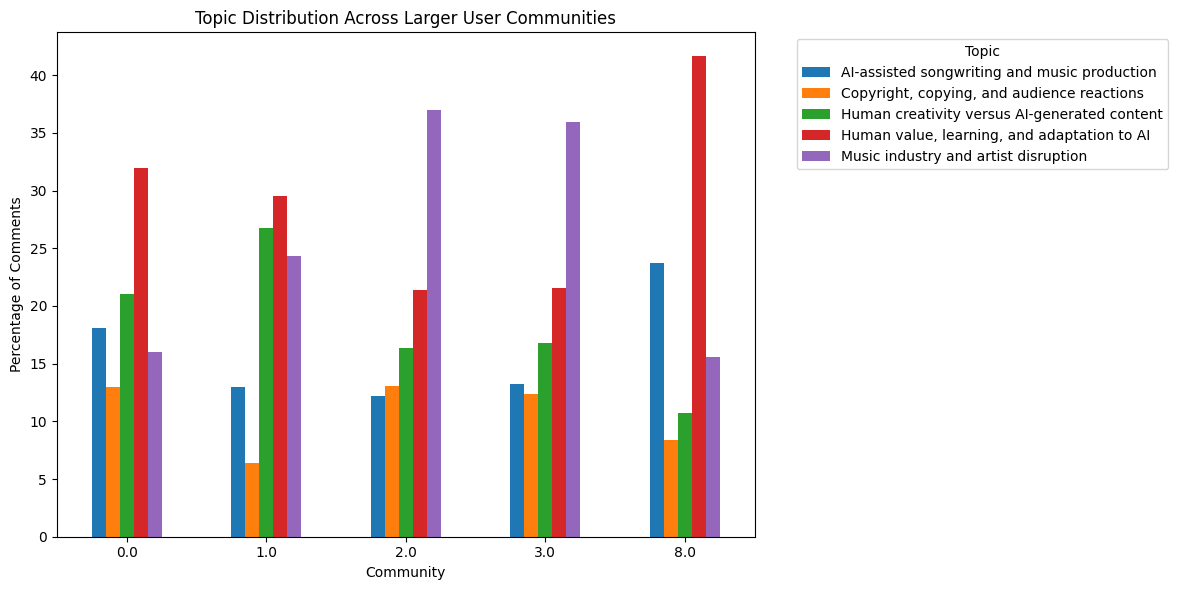

In [52]:
# Plot larger communities per topic
pivot_community_topics = largest_community_topics.pivot(
    index='author_community',
    columns='topic_label',
    values='percentage'
).fillna(0)

pivot_community_topics.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Topic Distribution Across Larger User Communities')
plt.xlabel('Community')
plt.ylabel('Percentage of Comments')
plt.xticks(rotation=0)
plt.legend(title='Topic', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

The chart compares the dominant LDA topics across the five largest user communities detected in the YouTube reply network. Overall, the results suggest that different interaction communities focus on different aspects of AI’s impact on the music sector.

- Communities 0, 1, and 4 are most strongly associated with **“Human value, learning, and adaptation to AI”**, suggesting that many users in these groups discuss broader questions about how people, artists, and workers may adapt to AI technologies. This indicates that the discussion is not only about music production itself, but also about the wider social and human implications of generative AI.

- Community 3 has the highest proportion of comments related to **“AI-assisted songwriting and music production”**. This suggests that users in this community are more focused on the practical use of AI tools for creating songs, lyrics, melodies, and recordings. Compared with the other communities, this group appears more centred on AI as a music-making tool.

- Community 4 shows a particularly high proportion of comments about **“Human creativity versus AI-generated content”** as well as human adaptation. This may indicate that users in this cluster are actively debating whether AI-generated music can be considered creative, authentic, or comparable to human-made art.

- Across all five communities, **“Copying, copyright, and audience reactions”** appears consistently but is not the dominant topic in most groups. This suggests that copyright and copying are relevant concerns, but the larger discussion is more strongly shaped by human creativity, adaptation, and AI-assisted music creation.

Overall, this plot shows that the network communities are not identical in their discussion patterns. The combination of community detection and topic modelling helps show how different groups of users frame AI’s impact on the music sector in different ways.

In [53]:
# This table finds the most common topic inside each user community.
# It helps us summarise what each community mainly talks about.

top_topic_per_community = (
    community_topic_summary
    # Sort by community first, then by comment count from highest to lowest
    .sort_values(
        ['author_community', 'comment_count'],
        ascending=[True, False]
    )
    # For each community, keep only the topic with the highest comment count
    .groupby('author_community')
    .head(1)
    .reset_index(drop=True)
)

# Display only the largest 5 communities, because these are the ones shown in the plot
top_topic_per_community[
    top_topic_per_community['author_community'].isin(largest_communities)
]

,author_community,topic_label,comment_count,community_total,percentage
0,0.0,"Human value, learning, and adaptation to AI",286,895,31.96
1,1.0,"Human value, learning, and adaptation to AI",223,755,29.54
2,2.0,Music industry and artist disruption,301,813,37.02
3,3.0,Music industry and artist disruption,255,709,35.97
8,8.0,"Human value, learning, and adaptation to AI",209,502,41.63


In [54]:
"""
This section prints example comments from each of the largest communities.
The aim is to check whether the topic labels make sense when compared with real comments.
"""
for community_id in largest_communities:
    print(f'\n---------------------------')
    print(f'Community {int(community_id)}')

    # Select comments written by users in this community
    community_comments = dataset[
        dataset['author_community'] == community_id
    ]

    # Find the most common topic in this community
    most_common_topic = (
        community_comments['topic_label']
        .value_counts()
        .idxmax()
    )

    print(f'Most common topic: {most_common_topic}')
    print('\nExample comments:')

    # Select high-confidence comments from the dominant topic
    example_comments = (
        community_comments[
            community_comments['topic_label'] == most_common_topic
        ]
        .sort_values('dominant_topic_probability', ascending=False)
        .head(3)
    )

    # Print a short version of each example comment
    for _, row in example_comments.iterrows():
        print('-', row['text'][:300])


---------------------------
Community 0
Most common topic: Human value, learning, and adaptation to AI

Example comments:
- Yep. We're all good little money piggies, first trained to believe that purchases are the key to happiness and status, now adequately conditioned to find furfillment in choking down nonsense slop isolated from human connection.
fr though it's fustrating. I didn't really think about it until a friend
- As a photographer, I don't feel threatened by ai generation at all. (Granted, I am a hobbyist, not someone pursuing it professionally). The act of finding something to photograph and later share cannot be replaced by a mere prompt. The process of working with a model and having our interaction becom
- @Xenderman You are the one who doesn't understand art, you can make art using AI, is that simple. The same argument was made for photography against painting. "It's too easiy", "the machine does it all for you" "It's gonna destroy the art of painting" And still there a

### 9.1. Community Sentiment Analysis

After community detection, sentiment labels were compared across the largest user communities. This helps show whether different interaction groups express different emotional orientations toward AI and music.

In [55]:
# Select top 5 communities based on comments
largest_communities = (
    dataset['author_community']
    .dropna()
    .value_counts()
    .head(5)
    .index
    .tolist()
)

# Keep only comments from the largest communities
largest_community_sentiment_data = dataset[
    dataset['author_community'].isin(largest_communities)
].copy()

# Count sentiment labels inside each community
community_sentiment_summary = (
    largest_community_sentiment_data
    .groupby(['author_community', 'sentiment_label'])
    .size()
    .reset_index(name='count')
)

# Calculate total comments per community
community_sentiment_summary['community_total'] = (
    community_sentiment_summary
    .groupby('author_community')['count']
    .transform('sum')
)

# Convert counts into percentages
community_sentiment_summary['percentage'] = (
    community_sentiment_summary['count'] /
    community_sentiment_summary['community_total'] * 100
).round(2)

community_sentiment_summary.head()

,author_community,sentiment_label,count,community_total,percentage
0,0.0,Negative,331,895,36.98
1,0.0,Neutral,146,895,16.31
2,0.0,Positive,418,895,46.70
3,1.0,Negative,207,755,27.42
4,1.0,Neutral,119,755,15.76


In [56]:
community_sentiment_pivot = community_sentiment_summary.pivot(
    index='author_community',
    columns='sentiment_label',
    values='percentage'
).fillna(0)

community_sentiment_pivot

sentiment_label,Negative,Neutral,Positive
author_community,,,
0.0,36.98,16.31,46.70
1.0,27.42,15.76,56.82
2.0,27.55,16.85,55.60
3.0,25.25,19.75,55.01
8.0,27.29,14.54,58.17


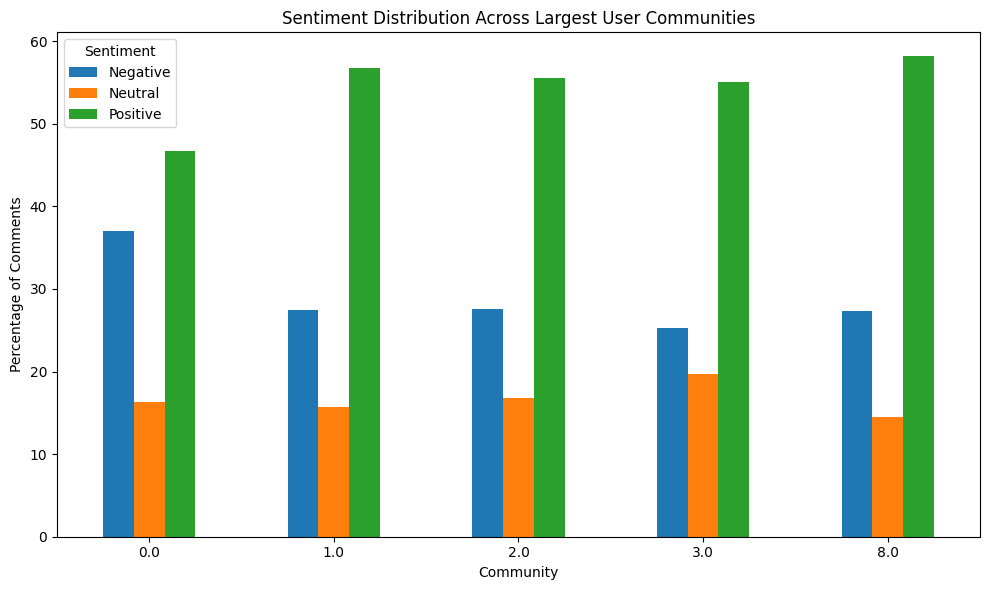

In [57]:
# Plot community sentiment distribution
community_sentiment_pivot.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Sentiment Distribution Across Largest User Communities')
plt.xlabel('Community')
plt.ylabel('Percentage of Comments')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

This plot compares the proportions of positive, neutral, and negative comments across the five largest user communities detected in the reply network. Overall, positive sentiment is the largest category in every major community, suggesting that the discussion around AI and music is generally more positive than negative across the main interaction groups.

However, the balance of sentiment differs between communities. Community 0 has the highest proportion of negative comments among the five largest communities, while its positive proportion is lower than the other groups. This may suggest that Community 0 contains more critical or cautious discussion about AI’s impact on music.

Communities 1, 2, 3, and 4 show stronger positive sentiment, with positive comments making up more than half of the comments in these communities. This suggests that these groups may be more favourable toward AI music tools, AI-assisted creativity, or the broader role of AI in the music sector.

Neutral sentiment appears in all communities but is consistently smaller than positive sentiment. These neutral comments may include factual statements, short replies, questions, or comments where VADER did not detect strong emotional polarity.

Overall, this plot adds a semantic layer to the network analysis. It shows that the detected user communities are not only different in their interaction patterns and topic focus, but also vary in their emotional orientation toward AI and music. Combined with the community-topic analysis, this suggests that different user communities vary not only in what they discuss, but also in how positively or negatively they discuss AI’s role in the music sector.